In [8]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
# Load data
nodes_df = pd.read_csv("graph_nodes.csv")
edges_df = pd.read_csv("graph_edges.csv")

print(nodes_df.head())
print(edges_df.head())

     name  gender
0    Alex    Male
1   Bella  Female
2  Carlos    Male
3    Dina  Female
4     Eli    Male
   Source  Target  Weight
0    Alex   Bella       3
1    Alex  Carlos       2
2   Bella    Dina       5
3  Carlos     Eli       4
4    Dina     Eli       2


In [2]:
# Create graph
G = nx.Graph()
for _, row in nodes_df.iterrows():
    G.add_node(row['name'], gender=row['gender'])
for _, row in edges_df.iterrows():
    G.add_edge(row['Source'], row['Target'], weight=row['Weight'])

In [3]:
# Layout
pos = nx.spring_layout(G, seed=42)
# Style: color by gender
gender_colors = {'Male': 'skyblue', 'Female': 'lightcoral'}
node_colors = [gender_colors[G.nodes[node]['gender']] for node in G.nodes]
# Size by degree
node_sizes = [G.degree(node)*500 for node in G.nodes]

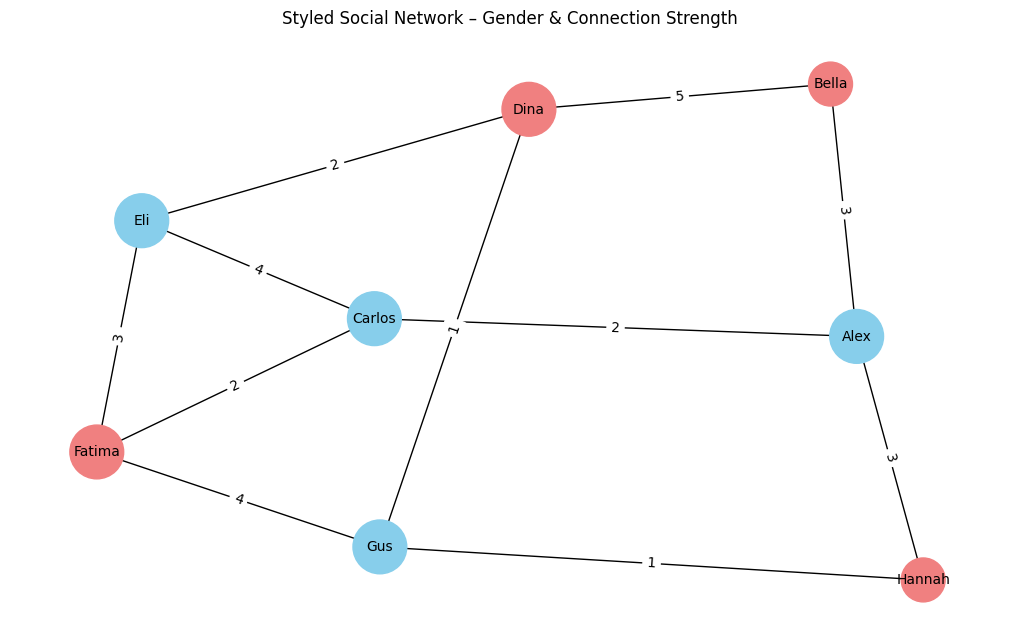

In [4]:
# Draw
plt.figure(figsize=(10,6))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=node_sizes, font_size=10)
# Edge weights
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("Styled Social Network – Gender & Connection Strength")
plt.show()

In [12]:
#Checking centrality
centrality = nx.betweenness_centrality(G)
print("\nBetweenness Centrality:")
for node, centrality_score in centrality.items():
    print(f"{node}: {round(centrality_score, 3)}")


Betweenness Centrality:
Alex: 0.175
Bella: 0.048
Carlos: 0.127
Dina: 0.167
Eli: 0.087
Fatima: 0.087
Gus: 0.167
Hannah: 0.048


In [9]:
#The most central connector
#Who appears to be a central connector?
central_connector = nx.betweenness_centrality(G)
top_connector = max(central_connector, key=central_connector.get) #Tells max() to compare the scores and not the string values of names
print(f"\nThe central connector is {top_connector} with a weight of: {round(central_connector[top_connector],3)}")


The central connector is Alex with a score of: 0.175


In [14]:
#Finding if there is a gender discrepancy
print("Everyone's centrality score:")
for node in G.nodes():
    score = centrality[node]
    gender = G.nodes[node]['gender']
    print(f"{node} ({gender}): {round(score, 3)}")


Everyone's centrality score:
Alex (Male): 0.175
Bella (Female): 0.048
Carlos (Male): 0.127
Dina (Female): 0.167
Eli (Male): 0.087
Fatima (Female): 0.087
Gus (Male): 0.167
Hannah (Female): 0.048


In [15]:
# Step 2: Print each person's score and gender
all_scores = list(centrality.values())
average = sum(all_scores) / len(all_scores)
print(f"\nAverage centrality score: {round(average, 3)}")


Average centrality score: 0.113


In [16]:
# Step 4: Check who is below average (peripheral)
print("\nPeople who are peripheral (below average):")
for node in G.nodes():
    score = centrality[node]
    gender = G.nodes[node]['gender']
    if score < average:
        print(f"{node} ({gender}): {round(score, 3)}")


People who are peripheral (below average):
Bella (Female): 0.048
Eli (Male): 0.087
Fatima (Female): 0.087
Hannah (Female): 0.048


In [19]:
# Step 5: Count how many of each gender are peripheral
male_peripheral = 0
female_peripheral = 0

for node in G.nodes():
    score = centrality[node]
    gender = G.nodes[node]['gender']
    if score < average:
        if gender == "Male":
            male_peripheral += 1
        else:
            female_peripheral += 1
print(f"\nNumber of peripheral males: {male_peripheral}")
print(f"Number of peripheral females: {female_peripheral}")


Number of peripheral males: 1
Number of peripheral females: 3
